## 使用CNN 辨識 CIFAR10 資料集
#### 程式修改自[『TRAINING A CLASSIFIER』](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)

## 載入套件

In [ ]:
import sys
from pathlib import Path
from typing import List, Sized, cast

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

In [ ]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑

## 判斷是否使用GPU

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'cpu'

## 載入資料集

In [ ]:
# 資料轉換
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        # 讀入圖像範圍介於[0, 1]之間，將之轉換為 [-1, 1]
        # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        # ImageNet
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

# 批量
batch_size = 1000

# 載入資料集，如果出現 BrokenPipeError 錯誤，將 num_workers 改為 0
train_ds = datasets.CIFAR10(PATH_DATASETS, train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10(PATH_DATASETS, train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


## 資料集共10種類別

In [4]:
classes = sorted(set(test_ds.classes))
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [5]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## 顯示圖片資料

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


torch.Size([8, 3, 32, 32])


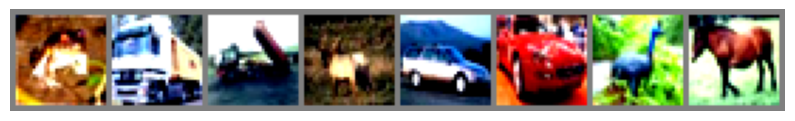

frog  truck truck deer  car   car   bird  horse


In [6]:
# 圖像顯示函數
def imshow(img: torch.Tensor) -> None:
    img = img * 0.5 + 0.5  # 還原圖像
    npimg = img.numpy()
    # 顏色換至最後一維
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()


# 取一筆資料
batch_size_tmp = 8
train_loader_tmp = DataLoader(train_ds, batch_size=batch_size_tmp)
images, labels = next(iter(train_loader_tmp))
print(images.shape)

# 顯示圖像
plt.figure(figsize=(10, 6))
imshow(torchvision.utils.make_grid(images))
# 顯示類別
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size_tmp)))

## 建立CNN模型

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 顏色要放在第1維，3:RGB三顏色
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x: torch.Tensor):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        #         x = F.log_softmax(x, dim=1)
        return x

## 訓練模型

In [ ]:
def train(
    model: nn.Module,
    device: str,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    epoch: int,
) -> List[float]:
    model.train()
    loss_list: list[float] = []
    data: torch.Tensor
    target: torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output: torch.Tensor = model(data)
        loss: torch.Tensor = criterion(output, target)
        loss.backward()
        optimizer.step()

        if (batch_idx + 1) % 10 == 0:
            loss_list.append(loss.item())
            batch = (batch_idx + 1) * len(data)
            data_count = len(cast(Sized, train_loader.dataset))
            percentage = 100.0 * (batch_idx + 1) / data_count
            print(f'Epoch {epoch}: [{batch:5d} / {data_count}] ({percentage:.0f} %)  Loss: {loss.item():.6f}')
    return loss_list

In [ ]:
def test(model: nn.Module, device: str, test_loader: DataLoader):
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        data: torch.Tensor
        target: torch.Tensor
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output: torch.Tensor = model(data)
            _, predicted = torch.max(output.data, 1)
            correct += (predicted == target).sum().item()

    # 平均損失
    data_count = len(cast(Sized, test_loader.dataset))
    test_loss /= data_count
    # 顯示測試結果
    percentage = 100.0 * correct / data_count
    print(f'準確率: {correct}/{data_count} ({percentage:.2f}%)')

In [10]:
epochs = 10
lr = 0.1

# 建立模型
model = Net().to(device)

# 定義損失函數
# 注意，nn.CrossEntropyLoss是類別，要先建立物件，要加 ()，其他損失函數不需要
criterion = nn.CrossEntropyLoss()  # F.nll_loss

# 設定優化器(optimizer)
# optimizer = optim.Adadelta(model.parameters(), lr=lr)
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

loss_list = []
for epoch in range(1, epochs + 1):
    loss_list += train(model, device, train_loader, criterion, optimizer, epoch)
    # test(model, device, test_loader)
    optimizer.step()

Epoch 1: [10000 / 50000] (0 %)  Loss: 2.273233
Epoch 1: [20000 / 50000] (0 %)  Loss: 2.089442
Epoch 1: [30000 / 50000] (0 %)  Loss: 1.954122
Epoch 1: [40000 / 50000] (0 %)  Loss: 2.294351
Epoch 1: [50000 / 50000] (0 %)  Loss: 2.247274
Epoch 2: [10000 / 50000] (0 %)  Loss: 2.153608
Epoch 2: [20000 / 50000] (0 %)  Loss: 1.960805
Epoch 2: [30000 / 50000] (0 %)  Loss: 1.839947
Epoch 2: [40000 / 50000] (0 %)  Loss: 1.700358
Epoch 2: [50000 / 50000] (0 %)  Loss: 1.676065
Epoch 3: [10000 / 50000] (0 %)  Loss: 2.027321
Epoch 3: [20000 / 50000] (0 %)  Loss: 1.888073
Epoch 3: [30000 / 50000] (0 %)  Loss: 1.740162
Epoch 3: [40000 / 50000] (0 %)  Loss: 1.743382
Epoch 3: [50000 / 50000] (0 %)  Loss: 1.714421
Epoch 4: [10000 / 50000] (0 %)  Loss: 1.685766
Epoch 4: [20000 / 50000] (0 %)  Loss: 1.613127
Epoch 4: [30000 / 50000] (0 %)  Loss: 1.557159
Epoch 4: [40000 / 50000] (0 %)  Loss: 1.592410
Epoch 4: [50000 / 50000] (0 %)  Loss: 1.504744
Epoch 5: [10000 / 50000] (0 %)  Loss: 1.530822
Epoch 5: [200

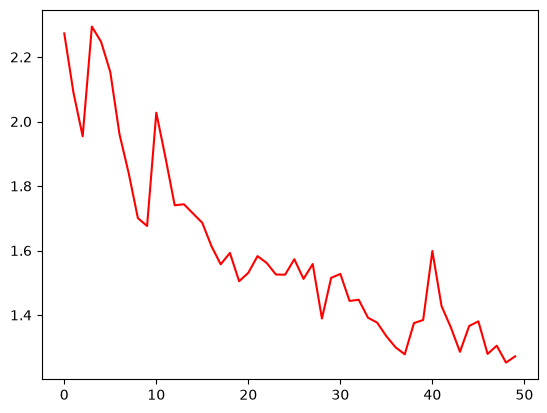

In [11]:
# 對訓練過程的損失繪圖
plt.plot(loss_list, 'r')

## 模型存檔

In [ ]:
PATH = base_path / 'cifar_net.pth'
torch.save(model.state_dict(), PATH)

In [13]:
model = Net()
model.load_state_dict(torch.load(PATH))
model.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## 評分

In [14]:
test(model, device, test_loader)

準確率: 4704/10000 (47.04%)


## 測試一批資料

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


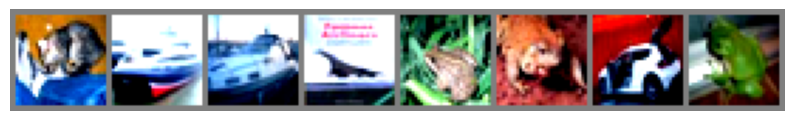

真實類別:  cat   ship  ship  plane frog  frog  car   frog 
預測類別:  cat   ship  car   ship  deer  frog  truck frog 


In [15]:
batch_size = 8
test_loader = DataLoader(test_ds, batch_size=batch_size)
images, labels = next(iter(test_loader))

# 顯示圖像
plt.figure(figsize=(10, 6))
imshow(torchvision.utils.make_grid(images))

print('真實類別: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

# 預測
outputs: torch.Tensor = model(images.to(device))

_, predicted = torch.max(outputs, 1)

print('預測類別: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(batch_size)))

## 計算各類別的準確率

In [ ]:
# 初始化各類別的正確數
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# 預測
batch_size = 1_000
test_loader = DataLoader(test_ds, batch_size=batch_size)
model.eval()
with torch.no_grad():
    data: torch.Tensor
    target: torch.Tensor
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs: torch.Tensor = model(data)
        _, predictions = torch.max(outputs, 1)
        # 計算各類別的正確數
        for label, prediction in zip(target, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# 計算各類別的準確率
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'{classname:5s}: {accuracy:.1f} %')

plane: 32.3 %
car  : 63.1 %
bird : 47.9 %
cat  : 21.0 %
deer : 49.2 %
dog  : 25.4 %
frog : 56.4 %
horse: 48.5 %
ship : 63.4 %
truck: 63.2 %
